In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


In [2]:
n_scaling_cpu=pd.read_csv('results_n_scaling_cpu.csv')
n_scaling_gpu=pd.read_csv('results_n_scaling.csv')

In [3]:
# Combine the data into a single DataFrame
df = pd.concat([n_scaling_cpu, n_scaling_gpu], axis=0, ignore_index=True)


In [4]:
df = df.sort_values(['run', 'n'])

In [5]:
df = df.reset_index(drop=True)

In [6]:
df['method'].unique()

<StringArray>
['cpu_4', 'cpu_8', 'cpu_16', 'cpu_36', 'author', 'cuda']
Length: 6, dtype: str

In [7]:
def aggregate(rows, point_key="point"): 
    agg = {} 
    for r in rows: 
        key = (r[point_key], r["method"]) 
        agg.setdefault(key, []).append(r["total_s"]) 
        summary = {} 
        for key, times in agg.items(): 
            arr = np.array(times) 
            summary[key] = ( 
                arr.mean(), 
                arr.std(ddof=1) if len(arr) > 1 else 0.0, 
                len(arr), 
                )
    return summary

def plot_scaling(rows, point_key, point_label, title, out_path,
                 log_x=True, log_y=True):
    if not rows:
        print("No data to plot.")
        return

    summary = aggregate(rows, point_key)
    points = sorted({k[0] for k in summary.keys()})

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    # --- methods ---
    methods = ['cpu_4', 'cpu_8', 'cpu_16', 'cpu_36', 'author', 'cuda']

    # high-contrast palette
    colors = [
        '#1f77b4',  # cpu_4   - blue
        '#ff7f0e',  # cpu_8   - orange
        '#2ca02c',  # cpu_16  - green
        '#d62728',  # cpu_36  - red
        '#9467bd',  # author  - purple
        '#000000',  # cuda    - black
    ]

    markers = ['o', 's', '^', 'v', 'P', 'D']
    linestyles = ['-', '--', '-.', ':', '-', '-']

    # --- Left: total time ---
    ax = axes[0]
    for method, color, marker, ls in zip(methods, colors, markers, linestyles):
        means = [summary.get((p, method), (np.nan,) * 3)[0] for p in points]
        stds  = [summary.get((p, method), (np.nan,) * 3)[1] for p in points]

        ax.errorbar(points, means,
                    label=method,
                    color=color,
                    marker=marker,
                    linestyle=ls,
                    capsize=3,
                    lw=2)

    if log_x: ax.set_xscale("log")
    if log_y: ax.set_yscale("log")
    ax.set_xlabel(point_label)
    ax.set_ylabel("Total time per fit (seconds)")
    ax.set_title(f"{title}: total time")
    ax.grid(True, which="major", alpha=0.3)
    ax.grid(False, which="minor")
    ax.legend()

    # --- Right: speedup (relative to 'author') ---
    ax = axes[1]
    baseline = 'author'

    for method, color, marker, ls in zip(methods, colors, markers, linestyles):
        if method == baseline:
            continue

        speedups, speedups_std = [], []
        for p in points:
            a = summary.get((p, baseline))
            m = summary.get((p, method))

            if a is None or m is None or m[0] == 0:
                speedups.append(np.nan)
                speedups_std.append(0)
                continue

            s = a[0] / m[0]
            rel_var = ((a[1] / a[0]) ** 2 + (m[1] / m[0]) ** 2
                       if a[0] and m[0] else 0)

            speedups.append(s)
            speedups_std.append(s * np.sqrt(rel_var))

        ax.errorbar(points, speedups, # yerr=speedups_std,
                    label=method,
                    color=color,
                    marker=marker,
                    linestyle=ls,
                    capsize=3,
                    lw=2)

    ax.axhline(1.0, color="grey", linestyle="--", alpha=0.6,
               label="parity (vs author)")

    if log_x: ax.set_xscale("log")
    ax.set_xlabel(point_label)
    ax.set_ylabel("Speedup (author time / method time)")
    ax.set_title(f"{title}: speedup")
    ax.grid(True, which="major", alpha=0.3)
    ax.grid(False, which="minor")
    ax.legend()

    fig.tight_layout()
    plt.show()

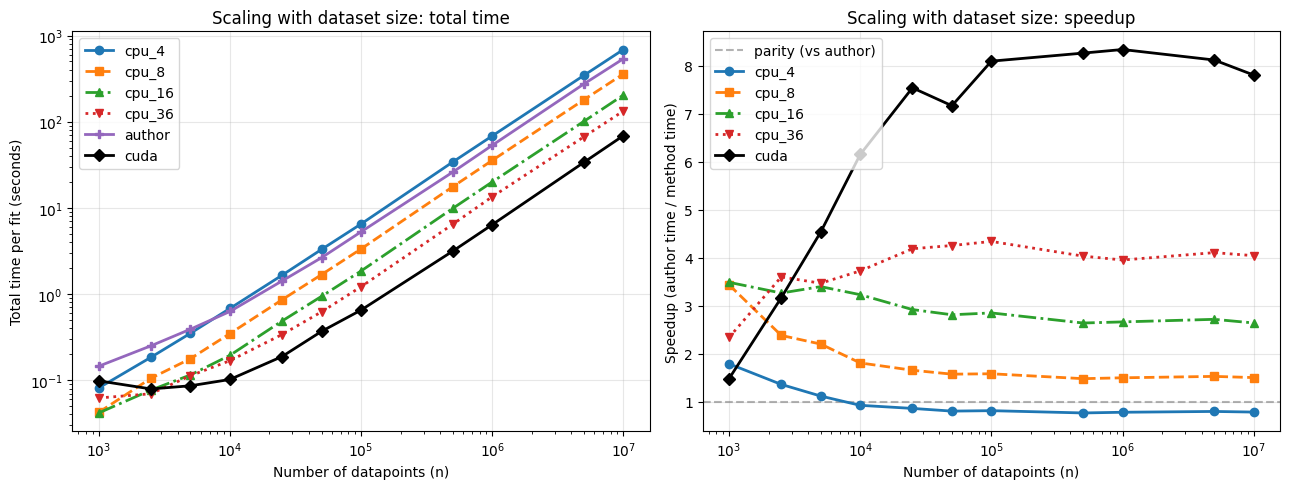

In [8]:
rows = df.to_dict(orient="records")
plot_scaling(rows, point_key="n", point_label="Number of datapoints (n)",
             title="Scaling with dataset size", out_path="scaling_n.png",
             log_x=True, log_y=True)

In [9]:
# %%
m_scaling_cpu=pd.read_csv('results_m_scaling_cpu.csv')
m_scaling_gpu=pd.read_csv('results_m_scaling.csv')

# %%
# Combine the data into a single DataFrame
df2 = pd.concat([m_scaling_cpu, m_scaling_gpu], axis=0, ignore_index=True)


# %%
df2 = df2.sort_values(['run', 'm'])

# %%
df2 = df2.reset_index(drop=True)

In [10]:
df2 = df2[df2['m'] != 12000]

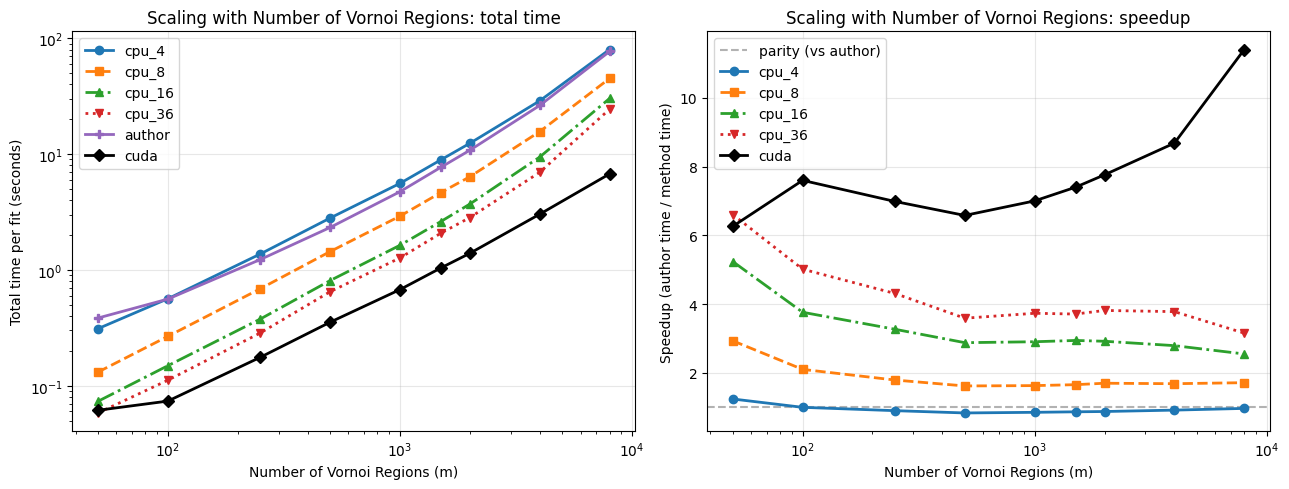

In [11]:
rows = df2.to_dict(orient="records")
plot_scaling(rows, point_key="m", point_label="Number of Vornoi Regions (m)",
             title="Scaling with Number of Vornoi Regions", out_path="scaling_m.png",
             log_x=True, log_y=True)